# Customer Intelligence & Segmentation Platform

## Notebook 03: Feature Engineering

### Objective

Transform transaction-level data into customer-level behavioral features for segmentation.

Features include:

- Recency
- Frequency
- Monetary Value
- Average Order Value
- Product Diversity
- Customer Tenure
- Average Basket Size

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv(
    "../data/processed/cleaned_data.csv"
)

df["InvoiceDate"] = pd.to_datetime(
    df["InvoiceDate"]
)

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [2]:
snapshot_date = (
    df["InvoiceDate"].max()
    + pd.Timedelta(days=1)
)

snapshot_date

Timestamp('2011-12-10 12:50:00')

In [3]:
recency = (
    df.groupby("CustomerID")
    ["InvoiceDate"]
    .max()
    .reset_index()
)

recency["Recency"] = (
    snapshot_date -
    recency["InvoiceDate"]
).dt.days

recency.head()

,CustomerID,InvoiceDate,Recency
0,12346,2011-01-18 10:01:00,326
1,12347,2011-12-07 15:52:00,2
2,12348,2011-09-25 13:13:00,75
3,12349,2011-11-21 09:51:00,19
4,12350,2011-02-02 16:01:00,310


In [4]:
frequency = (
    df.groupby("CustomerID")
    ["InvoiceNo"]
    .nunique()
    .reset_index()
)

frequency.columns = [
    "CustomerID",
    "Frequency"
]

In [5]:
monetary = (
    df.groupby("CustomerID")
    ["Revenue"]
    .sum()
    .reset_index()
)

monetary.columns = [
    "CustomerID",
    "Monetary"
]

In [6]:
customer_features = (
    recency[["CustomerID","Recency"]]
    .merge(
        frequency,
        on="CustomerID"
    )
    .merge(
        monetary,
        on="CustomerID"
    )
)

customer_features.head()

,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40


In [7]:
avg_order = (
    monetary["Monetary"] /
    frequency["Frequency"]
)

customer_features[
    "Avg_Order_Value"
] = avg_order

In [8]:
product_diversity = (
    df.groupby("CustomerID")
    ["StockCode"]
    .nunique()
    .reset_index()
)

product_diversity.columns = [
    "CustomerID",
    "Product_Diversity"
]

customer_features = (
    customer_features.merge(
        product_diversity,
        on="CustomerID"
    )
)

In [9]:
tenure = (
    df.groupby("CustomerID")
    ["InvoiceDate"]
    .agg(["min","max"])
    .reset_index()
)

tenure["Tenure"] = (
    tenure["max"] -
    tenure["min"]
).dt.days

customer_features = (
    customer_features.merge(
        tenure[
            ["CustomerID","Tenure"]
        ],
        on="CustomerID"
    )
)

In [10]:
basket_size = (
    df.groupby("CustomerID")
    ["Quantity"]
    .mean()
    .reset_index()
)

basket_size.columns = [
    "CustomerID",
    "Avg_Basket_Size"
]

customer_features = (
    customer_features.merge(
        basket_size,
        on="CustomerID"
    )
)

In [11]:
customer_features.info()

customer_features.head()

<class 'pandas.DataFrame'>
RangeIndex: 4338 entries, 0 to 4337
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         4338 non-null   int64  
 1   Recency            4338 non-null   int64  
 2   Frequency          4338 non-null   int64  
 3   Monetary           4338 non-null   float64
 4   Avg_Order_Value    4338 non-null   float64
 5   Product_Diversity  4338 non-null   int64  
 6   Tenure             4338 non-null   int64  
 7   Avg_Basket_Size    4338 non-null   float64
dtypes: float64(3), int64(5)
memory usage: 271.3 KB


,CustomerID,Recency,Frequency,Monetary,Avg_Order_Value,Product_Diversity,Tenure,Avg_Basket_Size
0,12346,326,1,77183.60,77183.600000,1,0,74215.000000
1,12347,2,7,4310.00,615.714286,103,365,13.505495
2,12348,75,4,1797.24,449.310000,22,282,75.516129
3,12349,19,1,1757.55,1757.550000,73,0,8.643836
4,12350,310,1,334.40,334.400000,17,0,11.588235


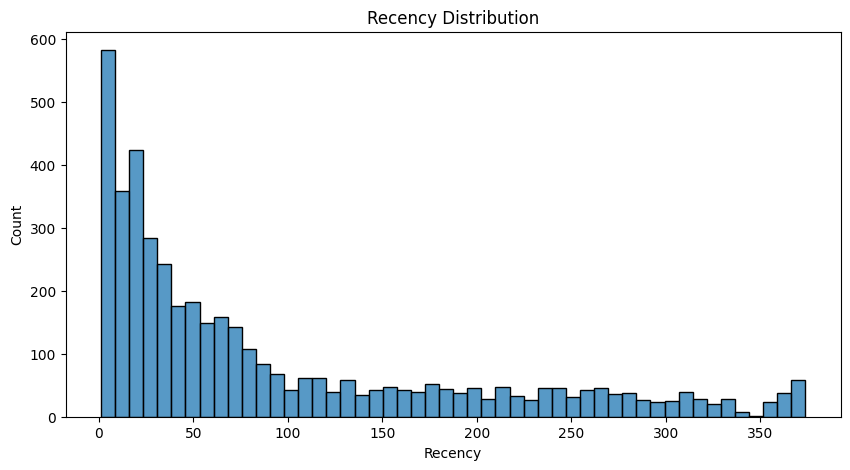

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

sns.histplot(
    customer_features["Recency"],
    bins=50
)

plt.title("Recency Distribution")
plt.show()

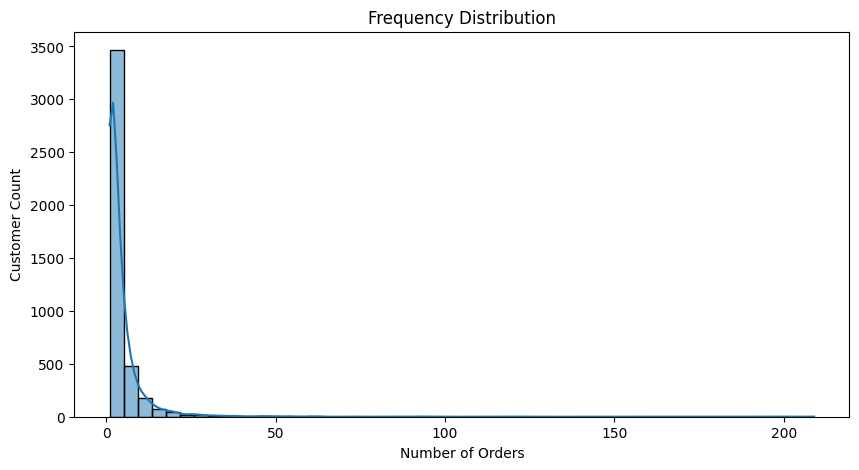

In [13]:
plt.figure(figsize=(10,5))

sns.histplot(
    customer_features["Frequency"],
    bins=50,
    kde=True
)

plt.title("Frequency Distribution")
plt.xlabel("Number of Orders")
plt.ylabel("Customer Count")

plt.show()

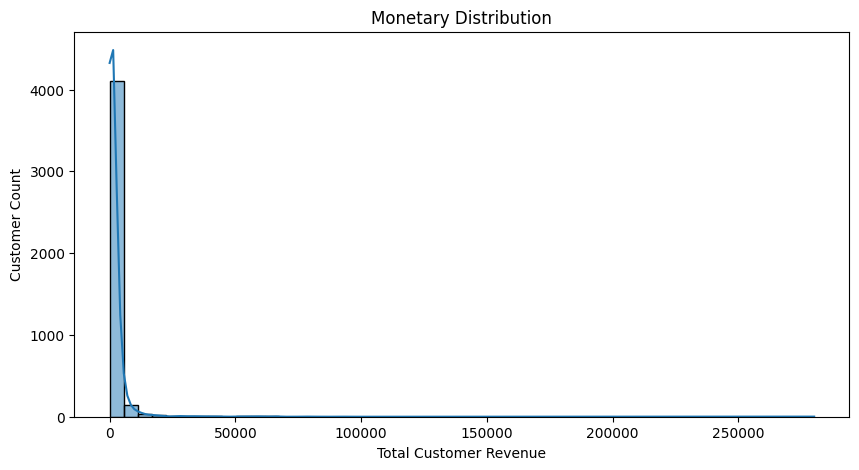

In [14]:
plt.figure(figsize=(10,5))

sns.histplot(
    customer_features["Monetary"],
    bins=50,
    kde=True
)

plt.title("Monetary Distribution")
plt.xlabel("Total Customer Revenue")
plt.ylabel("Customer Count")

plt.show()

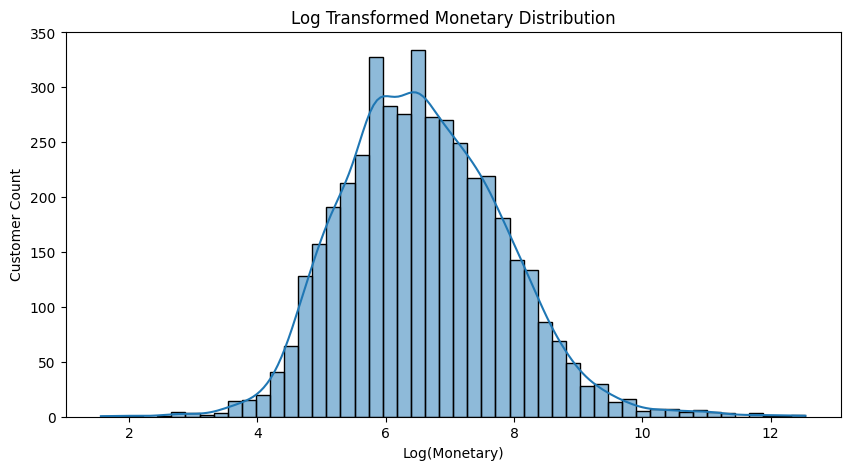

In [15]:
plt.figure(figsize=(10,5))

sns.histplot(
    np.log1p(customer_features["Monetary"]),
    bins=50,
    kde=True
)

plt.title("Log Transformed Monetary Distribution")
plt.xlabel("Log(Monetary)")
plt.ylabel("Customer Count")

plt.show()

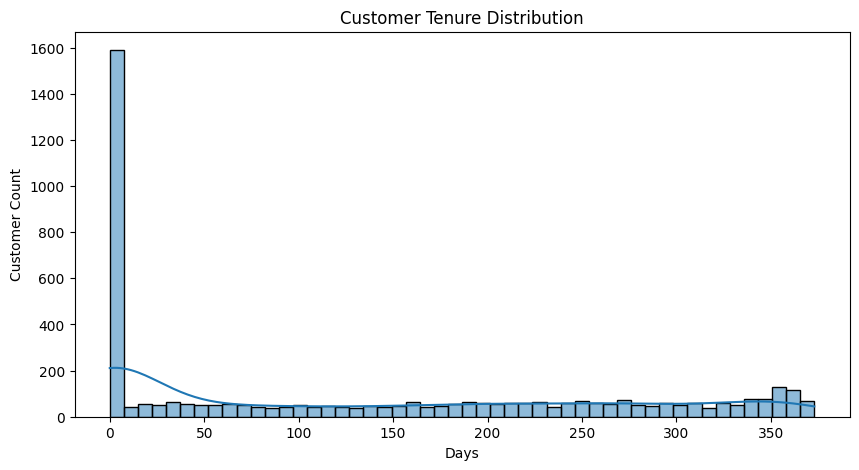

In [16]:
plt.figure(figsize=(10,5))

sns.histplot(
    customer_features["Tenure"],
    bins=50,
    kde=True
)

plt.title("Customer Tenure Distribution")
plt.xlabel("Days")
plt.ylabel("Customer Count")

plt.show()

In [17]:
customer_features.describe().T

,count,mean,std,min,25%,50%,75%,max
CustomerID,4338.0,15300.408022,1721.808492,12346.00,13813.250000,15299.50,16778.750000,18287.00
Recency,4338.0,92.536422,100.014169,1.00,18.000000,51.00,142.000000,374.00
Frequency,4338.0,4.272015,7.697998,1.00,1.000000,2.00,5.000000,209.00
Monetary,4338.0,2048.688081,8985.230220,3.75,306.482500,668.57,1660.597500,280206.02
Avg_Order_Value,4338.0,417.645735,1796.511343,3.45,177.867083,291.94,428.280625,84236.25
Product_Diversity,4338.0,61.501153,85.366768,1.00,16.000000,35.00,77.000000,1787.00
Tenure,4338.0,130.448594,132.039554,0.00,0.000000,92.50,251.750000,373.00
Avg_Basket_Size,4338.0,45.080599,1203.437983,1.00,6.042120,10.00,14.666667,74215.00


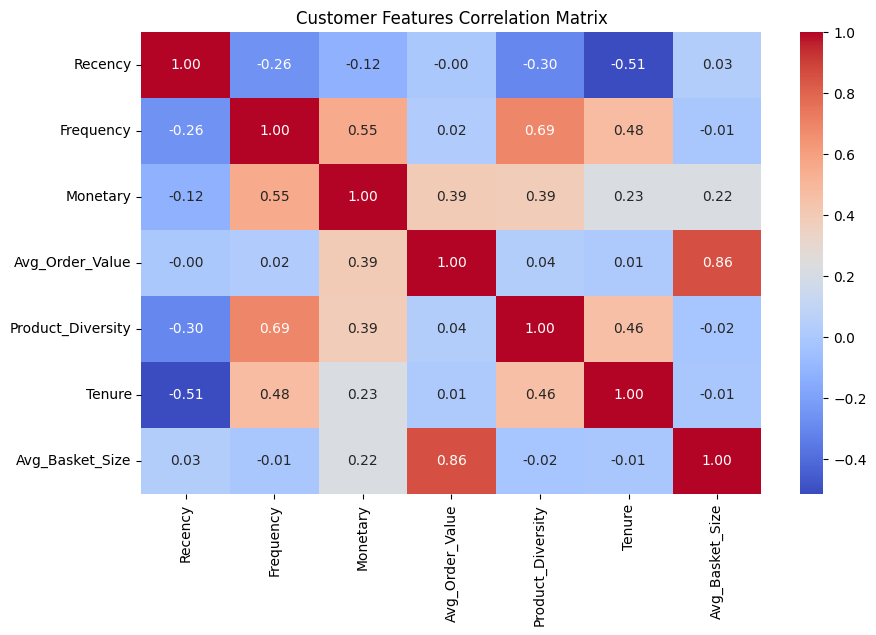

In [18]:
plt.figure(figsize=(10,6))

sns.heatmap(
    customer_features.drop("CustomerID", axis=1).corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Customer Features Correlation Matrix")

plt.show()

In [19]:
plt.savefig(
    "../outputs/charts/customer_feature_correlation.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [20]:
print(customer_features.shape)

customer_features.head()

(4338, 8)


,CustomerID,Recency,Frequency,Monetary,Avg_Order_Value,Product_Diversity,Tenure,Avg_Basket_Size
0,12346,326,1,77183.60,77183.600000,1,0,74215.000000
1,12347,2,7,4310.00,615.714286,103,365,13.505495
2,12348,75,4,1797.24,449.310000,22,282,75.516129
3,12349,19,1,1757.55,1757.550000,73,0,8.643836
4,12350,310,1,334.40,334.400000,17,0,11.588235


In [21]:
customer_features.to_csv(
    "../data/processed/customer_features.csv",
    index=False
)

print("customer_features.csv saved successfully")

customer_features.csv saved successfully
